3.	Import the required packages with their customary aliases as follows:

    `import pandas as pd`   
    `import numpy as np`  
    `import matplotlib.pyplot as plt`  
    `import seaborn as sns`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

4.	Using the pandas `read_csv()` method, read the GDP dataset into your notebook as a DataFrame called `gdp_df`. Take a look at the first few and last few rows to familiarize yourself with what is contained in this dataset.

In [2]:
gdp_df=pd.read_csv('../data/gdp_percapita.csv')

In [3]:
gdp_df.head()

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1992.424394,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN


In [4]:
gdp_df.tail()

,Country or Area,Year,Value,Value Footnotes
8214,Zimbabwe,1994,3965.730986,NaN
8215,Zimbabwe,1993,3634.750494,NaN
8216,Zimbabwe,1992,3649.891947,NaN
8217,Zimbabwe,1991,4126.405247,NaN
8218,Zimbabwe,1990,4013.299059,NaN


5. How many rows and columns are in `gdp_df`? What are the data types of each column?

In [5]:
gdp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8219 entries, 0 to 8218
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country or Area  8219 non-null   object 
 1   Year             8219 non-null   int64  
 2   Value            8219 non-null   float64
 3   Value Footnotes  0 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 257.0+ KB


6. Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'GDP_Per_Capita'.

In [6]:
gdp_df=gdp_df.drop(columns = ['Value Footnotes']).rename(columns={'Country or Area': 'Country','Value': 'GDP_Per_capita'})

In [7]:
gdp_df

,Country,Year,GDP_Per_capita
0,Afghanistan,2023,1992.424394
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8214,Zimbabwe,1994,3965.730986
8215,Zimbabwe,1993,3634.750494
8216,Zimbabwe,1992,3649.891947
8217,Zimbabwe,1991,4126.405247


7. How many countries have data for all years? Which countries are missing many years of data? Look at the number of observations per year. What do you notice?

In [8]:
total_years=gdp_df['Year'].nunique()

In [9]:
total_years

34

In [10]:
full_data=(gdp_df['Country'].value_counts()== 34).sum()

In [11]:
full_data

np.int64(228)

In [12]:
missing_data=gdp_df['Country'].value_counts().tail().sort_values()

In [13]:
missing_data

Country
Djibouti                     11
Turks and Caicos Islands     13
Sint Maarten (Dutch part)    15
Kosovo                       16
Faroe Islands                16
Name: count, dtype: int64

In [14]:
per_year=gdp_df['Year'].value_counts().sort_index()

In [15]:
per_year

Year
1990    233
1991    234
1992    234
1993    234
1994    235
1995    236
1996    236
1997    238
1998    238
1999    238
2000    240
2001    240
2002    241
2003    241
2004    241
2005    241
2006    242
2007    242
2008    244
2009    245
2010    245
2011    246
2012    246
2013    247
2014    247
2015    247
2016    247
2017    247
2018    247
2019    247
2020    247
2021    247
2022    246
2023    240
Name: count, dtype: int64

8. In this question, you're going to create some plots to show the distribution of GDP per capita for the year 2020. Go to the Python Graph Gallery (https://www.python-graph-gallery.com/) and look at the different types of plots under the Distribution section. Create a histogram, a density plot, a boxplot, and a violin plot. What do you notice when you look at these plots? How do the plots compare and what information can you get out of one type that you can't necessarily get out of the others?


In [16]:
df_2020=gdp_df.loc[gdp_df['Year']==2020]

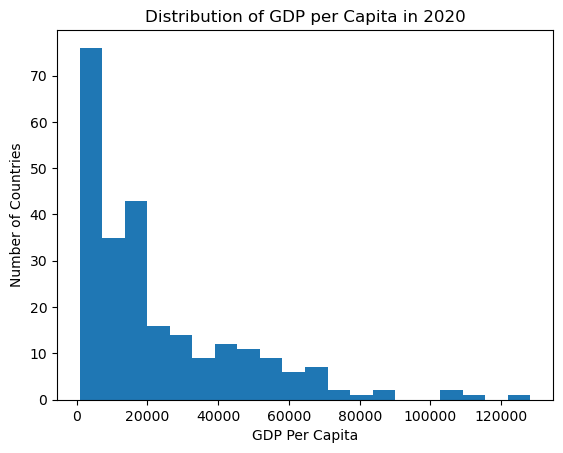

In [17]:
plt.hist(data=df_2020,x='GDP_Per_capita',bins=20)
plt.title('Distribution of GDP per Capita in 2020')
plt.xlabel('GDP Per Capita')
plt.ylabel('Number of Countries');

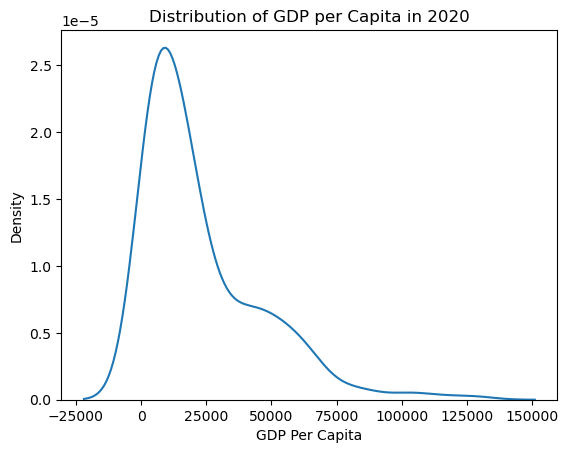

In [18]:
sns.kdeplot(data=df_2020,x='GDP_Per_capita')
plt.title('Distribution of GDP per Capita in 2020')
plt.xlabel('GDP Per Capita');

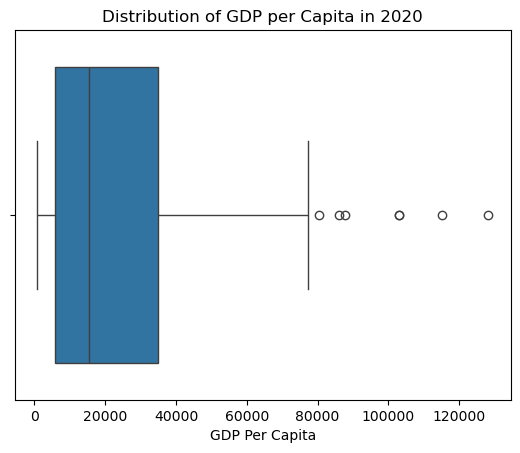

In [19]:
sns.boxplot(data=df_2020,x='GDP_Per_capita')
plt.title('Distribution of GDP per Capita in 2020')
plt.xlabel('GDP Per Capita');

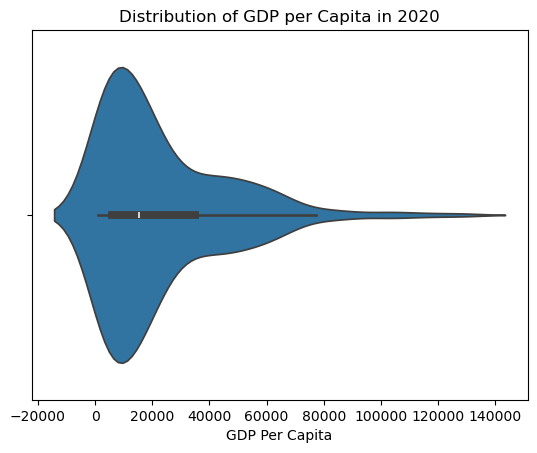

In [20]:
sns.violinplot(data=df_2020,x='GDP_Per_capita')
plt.title('Distribution of GDP per Capita in 2020')
plt.xlabel('GDP Per Capita');

9. What was the median GDP per capita value in 2020?

In [21]:
median_value =df_2020['GDP_Per_capita'].median()

In [22]:
median_value

15309.23598817024

10. For this question, you're going to create some visualizations to compare GDP per capita values for the years 1990, 2000, 2010, and 2020. Start by subsetting your data to just these 4 years into a new DataFrame named gdp_decades. Using this, create the following 4 plots:
	* A boxplot
	* A barplot (check out the Barplot with Seaborn section: https://www.python-graph-gallery.com/barplot/#Seaborn)
	* A scatterplot
	* A scatterplot with a trend line overlaid (see this regplot example: https://www.python-graph-gallery.com/42-custom-linear-regression-fit-seaborn)  
Comment on what you observe has happened to GDP values over time and the relative strengths and weaknesses of each type of plot.


In [23]:
decades=[1990,2000,2010,2020]

In [24]:
gdp_decades=gdp_df.loc[gdp_df['Year'].isin(decades)]

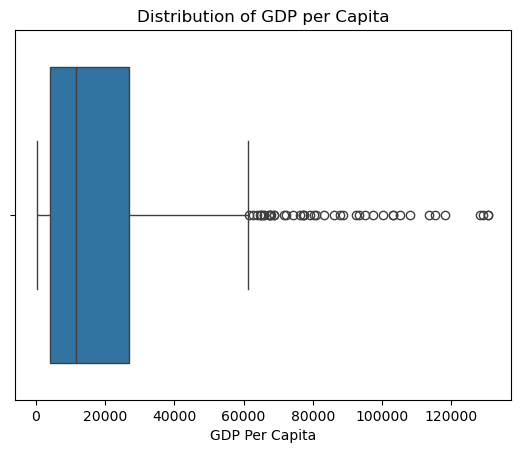

In [25]:
sns.boxplot(data=gdp_decades,x='GDP_Per_capita')
plt.title('Distribution of GDP per Capita')
plt.xlabel('GDP Per Capita');

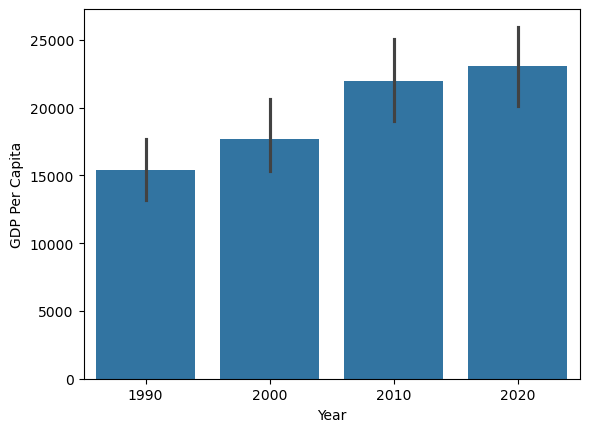

In [26]:
sns.barplot(data=gdp_decades,x='Year',y='GDP_Per_capita')
plt.ylabel('GDP Per Capita');

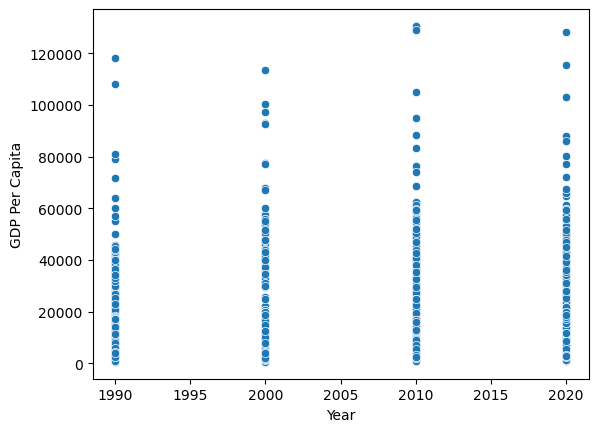

In [27]:
sns.scatterplot(data=gdp_decades,x='Year',y='GDP_Per_capita')
plt.ylabel('GDP Per Capita');

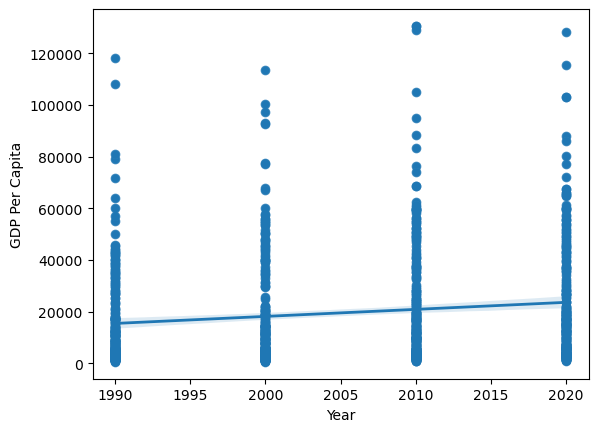

In [28]:
sns.scatterplot(data=gdp_decades,x='Year',y='GDP_Per_capita')
sns.regplot(data=gdp_decades,x='Year',y='GDP_Per_capita',line_kws={'linewidth':2})
plt.ylabel('GDP Per Capita');

11. Which country was the first to have a GDP per capita greater than $100,000?

In [29]:
over_100=gdp_df.loc[gdp_df['GDP_Per_capita'] >=100000]

In [30]:
over_100.sort_values(by='Year').head(1)

,Country,Year,GDP_Per_capita
974,Brunei,1990,118163.683198


12. Which country had the highest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

In [31]:
df_2020.sort_values(by='GDP_Per_capita',ascending=False).head(1)

,Country,Year,GDP_Per_capita
4426,Luxembourg,2020,128256.560341


13. Which country had the lowest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset. **Bonus question:** Is it true in general that coutries had a higher GDP per capita in 2020 than in 1990? Which countries had lower GDP per capita in 2020 than in 1990?

In [32]:
df_2020.sort_values(by='GDP_Per_capita',ascending=True).head(1)

,Country,Year,GDP_Per_capita
1046,Burundi,2020,833.920257


In [33]:
burundi=gdp_df.loc[gdp_df['Country']=='Burundi']

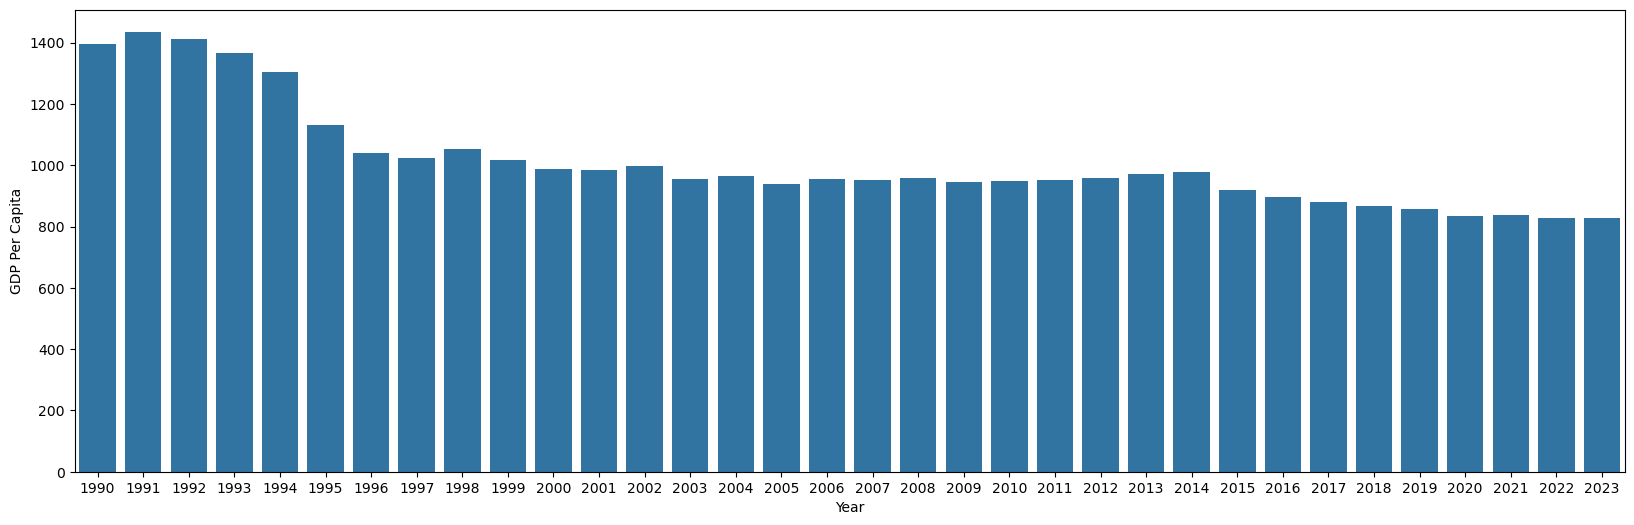

In [34]:
plt.figure(figsize=(20,6))
sns.barplot(data=burundi,x='Year',y='GDP_Per_capita')
plt.ylabel('GDP Per Capita');

In [35]:
year_1990=gdp_df.loc[gdp_df['Year']==1990]
year_2020=gdp_df.loc[gdp_df['Year']==2020]

In [36]:
year_1990.sort_values(by='GDP_Per_capita',ascending=True).head(1)

,Country,Year,GDP_Per_capita
5163,Mozambique,1990,547.622781


14. Read in the internet use dataset into a DataFrame named `internet_df`. You will likely get errors when doing this. Check the arguments for the read_csv function to find ones that can help correct the errors (https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) Once you are able to read it in, take per a look at the top and bottom few rows to make sure that it has been read in correctly. Also, check the datatypes of the columns.

In [37]:
internet_df=pd.read_csv('../data/internet_use.csv',nrows= 6083)

In [38]:
internet_df

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.600000,1
1,Afghanistan,2018,16.800000,2
2,Afghanistan,2017,13.500000,3
3,Afghanistan,2016,11.000000,4
4,Afghanistan,2015,8.260000,4
...,...,...,...,...
6078,Zimbabwe,1997,0.033080,NaN
6079,Zimbabwe,1996,0.016790,NaN
6080,Zimbabwe,1995,0.007684,NaN
6081,Zimbabwe,1994,0.001739,NaN


15. Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'Internet_Users_Pct'.

In [39]:
internet_df=internet_df.drop(columns = ['Value Footnotes']).rename(columns={'Country or Area': 'Country','Value': 'Internet_Users_Pct'})

In [40]:
internet_df

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


16. Look at the number of observations in this dataset per year. What do you notice?

In [41]:
per_year=internet_df['Year'].value_counts().sort_index()

In [42]:
per_year

Year
1990    226
1991     39
1992     50
1993     66
1994     92
1995    141
1996    177
1997    188
1998    195
1999    207
2000    210
2001    212
2002    214
2003    208
2004    210
2005    212
2006    212
2007    217
2008    214
2009    214
2010    209
2011    214
2012    209
2013    203
2014    204
2015    203
2016    206
2017    205
2018    174
2019    185
2020    186
2021    186
2022    184
2023     11
Name: count, dtype: int64

17. What is the first year to have a non-zero internet users percentage value?

In [43]:
non_0=internet_df.loc[internet_df['Internet_Users_Pct'] >0]

In [44]:
non_0.min()

Country               Afghanistan
Year                         1990
Internet_Users_Pct       0.000018
dtype: object

18. How does the distribution of internet users percent differ for 2000 and 2014?

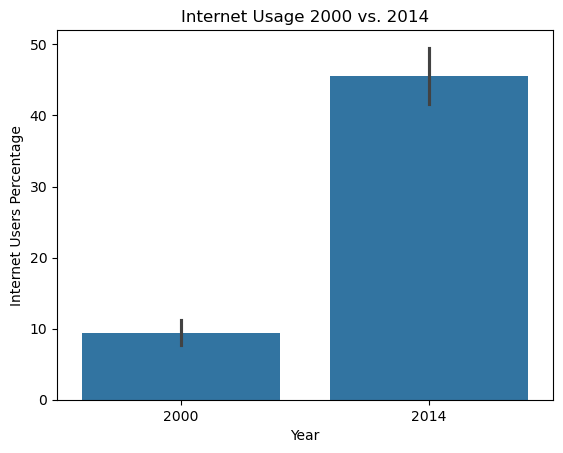

In [45]:
sns.barplot(data=internet_df[internet_df['Year'].isin([2000,2014])],x='Year', y='Internet_Users_Pct')
plt.ylabel('Internet Users Percentage')
plt.title ('Internet Usage 2000 vs. 2014');

19. For how many countries was the percentage of internet users below 5% in 2014?

In [46]:
below_5=internet_df.loc[(internet_df['Internet_Users_Pct'] <=5) & (internet_df['Year'] == 2014)]

In [47]:
below_5.shape

(10, 3)

20. Merge the two DataFrames to one. Do this in a way that keeps **all rows** from each of the two DataFrames. Call the new DataFrame `gdp_and_internet_use`. Look at the first and last few rows to confirm that it merged correctly.

In [48]:
gdp_and_internet_use= pd.merge(gdp_df,internet_df, on=['Country','Year'], how='inner')

In [49]:
gdp_and_internet_use

,Country,Year,GDP_Per_capita,Internet_Users_Pct
0,Afghanistan,2019,2927.245144,17.600000
1,Afghanistan,2018,2902.392113,16.800000
2,Afghanistan,2017,2952.998916,13.500000
3,Afghanistan,2016,2958.785399,11.000000
4,Afghanistan,2015,2967.692067,8.260000
...,...,...,...,...
4798,Zimbabwe,1997,4304.406272,0.033080
4799,Zimbabwe,1996,4271.479930,0.016790
4800,Zimbabwe,1995,3935.280057,0.007684
4801,Zimbabwe,1994,3965.730986,0.001739


21. Find the three countries with the highest internet users percentage in 2014. Use a seaborn FacetGrid (https://seaborn.pydata.org/generated/seaborn.FacetGrid.html) to compare how the GDP per capita has changed over time for these three countries. What do you notice?

In [50]:
top_three= gdp_and_internet_use[gdp_and_internet_use['Year'] == 2014]

In [51]:
top_three=top_three.sort_values(by='Internet_Users_Pct', ascending=False).head(3)

In [52]:
top_country=gdp_and_internet_use.loc[gdp_and_internet_use['Country'].isin(top_three['Country'])]

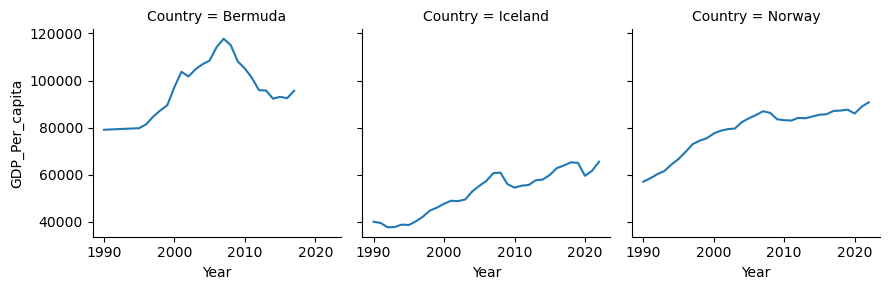

In [53]:
g=sns.FacetGrid(top_country,col='Country')
g.map_dataframe(sns.lineplot, x='Year',y='GDP_Per_capita');

22. Subset `gdp_and_internet_use` to just the year 2014. Save this as a new dataframe named `gdp_and_internet_use_2014`.

In [54]:
gdp_and_internet_use_2014=gdp_and_internet_use.loc[gdp_and_internet_use['Year'] ==2014]

23. Create a plot which compares Internet Users Percentage and GDP per Capita for the year 2014. What do you notice from this plot? If you see any unusual points, investigate them.

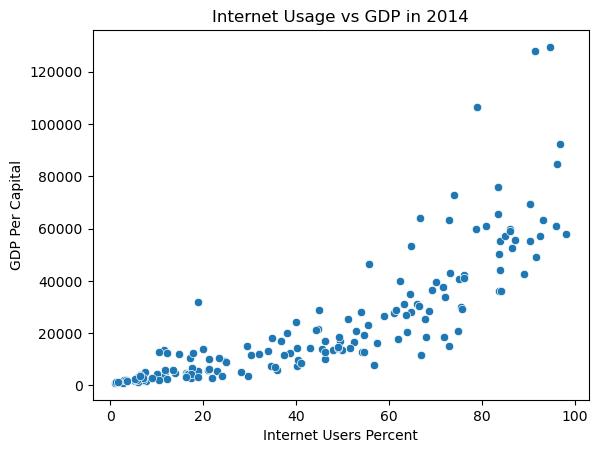

In [55]:
sns.scatterplot(data=gdp_and_internet_use_2014, x='Internet_Users_Pct',y='GDP_Per_capita')
plt.title ('Internet Usage vs GDP in 2014')
plt.ylabel ('GDP Per Capital')
plt.xlabel ('Internet Users Percent');

In [56]:
gdp_and_internet_use.to_csv('../data/gdp_and_internet_use.csv',index=False)

24. **Stretch Question:** Use the `qcut` function from pandas (https://pandas.pydata.org/docs/reference/api/pandas.qcut.html) to divide countries in `gdp_per_capita_2014` into three groups based on their GDP per capita values. Label these groups as "Low", "Medium", and "High". Put these labels in a new column, named "GDP_group".

In [57]:
gdp_and_internet_use_2014['GDP_group']=pd.qcut(gdp_and_internet_use_2014['GDP_Per_capita'],q=3, labels=['Low', 'Medium', 'High'])
gdp_and_internet_use_2014

C:\Users\lukem\AppData\Local\Temp\ipykernel_33040\1078984783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdp_and_internet_use_2014['GDP_group']=pd.qcut(gdp_and_internet_use_2014['GDP_Per_capita'],q=3, labels=['Low', 'Medium', 'High'])


,Country,Year,GDP_Per_capita,Internet_Users_Pct,GDP_group
5,Afghanistan,2014,3017.942544,7.0000,Low
27,Albania,2014,12788.747231,54.3000,Medium
56,Algeria,2014,15073.762940,29.5000,Medium
85,Andorra,2014,59929.244467,86.1000,High
112,Angola,2014,10250.592404,21.3623,Medium
...,...,...,...,...,...
4666,Uzbekistan,2014,7145.109807,35.5000,Low
4695,Vanuatu,2014,3320.379187,18.8000,Low
4723,Viet Nam,2014,8751.882806,41.0000,Medium
4751,Zambia,2014,3585.577485,6.5000,Low


25. **Stretch Question:** How does the median internet users percentage compare for the three gdp groups?

In [58]:
median_internet=gdp_and_internet_use_2014['Internet_Users_Pct'].median()

In [59]:
low_median=gdp_and_internet_use_2014.loc[gdp_and_internet_use_2014['GDP_group']=='Low','Internet_Users_Pct'].median()

In [60]:
medium_median=gdp_and_internet_use_2014.loc[gdp_and_internet_use_2014['GDP_group']=='Medium','Internet_Users_Pct'].median()

In [61]:
high_median=gdp_and_internet_use_2014.loc[gdp_and_internet_use_2014['GDP_group']=='High','Internet_Users_Pct'].median()

In [62]:
labels=['Overall', 'Low', 'Medium', 'High']
medians=[median_internet, low_median, medium_median, high_median]

Text(0, 0.5, 'Median Internet User %')

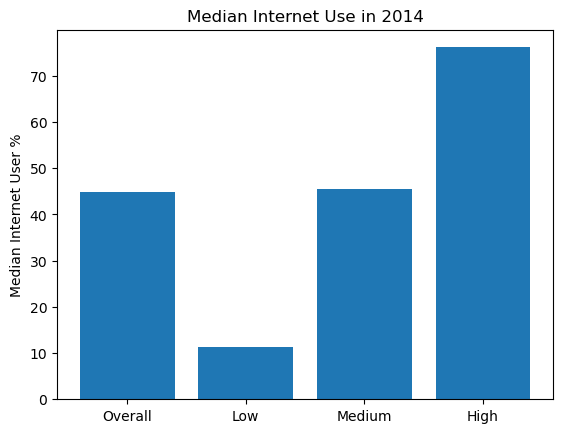

In [63]:
plt.bar(labels,medians)
plt.title ('Median Internet Use in 2014')
plt.ylabel('Median Internet User %')